In [2]:
import time
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

try:
    from ucimlrepo import fetch_ucirepo
    UCIMLREPO_AVAILABLE = True
except ImportError:
    UCIMLREPO_AVAILABLE = False


In [3]:
# Algo Naive Bayes
class NaiveBayes:
    def __init__(self, eps=1e-9):
        self.eps = eps

        #struktury danych 
        self.Xtrain = None
        self.Ytrain = None
        self.priors = None
        self.means = None
        self.variances = None
        self.class_labels = None

        self.classes = None
        self.class_to_index = None

    def fit(self, X_train, y_train):
        #uczenie- zapis danych + obliczenie priors, means i variances
        self.Xtrain = np.asarray(X_train, dtype=float)
        self.Ytrain = np.asarray(y_train)

        self.classes = np.unique(self.Ytrain)
        self.class_to_index = {label: i for i, label in enumerate(self.classes)}
        self.class_labels = {i: str(label) for i, label in enumerate(self.classes)}

        self.compute_priors(self.Ytrain)
        self.compute_gaussian_params(self.Xtrain, self.Ytrain)
        return self

    def compute_priors(self, y):
        #P(c) liczba próbek klasy c /wszystkie próbki
        y = np.asarray(y)
        self.priors = np.zeros(len(self.classes), dtype=float)

        for label in self.classes:
            idx = self.class_to_index[label]
            self.priors[idx] = np.sum(y == label) / len(y)

        return self.priors

    def compute_gaussian_params(self, X, y):
        #dla każdej klasy i cechy śrendia i wariancja
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)

        n_classes = len(self.classes)
        n_features = X.shape[1]
        self.means = np.zeros((n_classes, n_features), dtype=float)
        self.variances = np.zeros((n_classes, n_features), dtype=float)

        for label in self.classes:
            idx = self.class_to_index[label]
            X_class = X[y == label]
            self.means[idx] = np.mean(X_class, axis=0)
            self.variances[idx] = np.var(X_class, axis=0) + self.eps

        return self.means, self.variances

    def gaussian_pdf(self, x, mean, variance):
        #gęstość rozkładu normalnego dla cechy
        return (1.0 / np.sqrt(2.0 * np.pi * variance)) * np.exp(-((x - mean) ** 2) / (2.0 * variance))

    def log_posterior(self, x, class_label):
        #log P(C) + suma log P(x_i|C)
        idx = self.class_to_index[class_label]
        log_prior = np.log(self.priors[idx])

        pdf_values = self.gaussian_pdf(x, self.means[idx], self.variances[idx])
        log_likelihood = np.sum(np.log(pdf_values + self.eps))

        return log_prior + log_likelihood

    def predict(self, X_test):
        X_test = np.asarray(X_test, dtype=float)
        predictions = []

        for x in X_test:
            scores = [self.log_posterior(x, label) for label in self.classes]
            best_class = self.classes[int(np.argmax(scores))]
            predictions.append(best_class)

        return np.array(predictions)

    def predict_proba(self, X_test):
        #przybliżone prawdopodobieństwa po klasach po softmaxie
        X_test = np.asarray(X_test, dtype=float)
        all_probabilities = []

        for x in X_test:
            scores = np.array([self.log_posterior(x, label) for label in self.classes])
            scores = scores - np.max(scores)  # stabilność numeryczna
            exp_scores = np.exp(scores)
            probabilities = exp_scores / np.sum(exp_scores)
            all_probabilities.append(probabilities)

        return np.array(all_probabilities)

In [4]:
# Algo kNN
class KNN:
    def __init__(self, k=5):
        self.k = k

        #struktury danych 
        self.x_train = None
        self.y_train = None
        self.distances = None
        self.neighbors = None
        self.votes = None

    def fit(self, x_train, y_train):
        #leniwa tylko dane treningowe zapamiętaj
        self.x_train = np.asarray(x_train, dtype=float)
        self.y_train = np.asarray(y_train)
        return self

    def set_k(self, k):
        self.k = int(k)

    def euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))

    def get_neighbors(self, x):
        #pary:odległość, indeks_próbki, klasa
        self.distances = []

        for i in range(len(self.x_train)):
            dist = self.euclidean_distance(x, self.x_train[i])
            self.distances.append((dist, i, self.y_train[i]))

        self.distances.sort(key=lambda item: item[0])
        self.neighbors = self.distances[:self.k]
        return self.neighbors

    def predict_one(self, x):
        neighbors = self.get_neighbors(x)
        labels = [item[2] for item in neighbors]
        self.votes = dict(Counter(labels))

        #jak remis Counter wybiera jedną z najczęstszych klas
        return Counter(labels).most_common(1)[0][0]

    def predict(self, x_test):
        x_test = np.asarray(x_test, dtype=float)
        predictions = []

        for x in x_test:
            predictions.append(self.predict_one(x))

        return np.array(predictions)

In [6]:
# Przygotowanie danych - ładowanie datasetu przez ucimlrepo
def load_uci_dataset(dataset_id):
    if not UCIMLREPO_AVAILABLE:
        raise ImportError("brakuje biblioteki ucimlrepo zainstaluj")

    dataset = fetch_ucirepo(id=dataset_id)
    X_df = dataset.data.features.copy()
    y_df = dataset.data.targets.copy()

    if isinstance(y_df, pd.DataFrame):
        y = y_df.iloc[:, 0]
    else:
        y = pd.Series(y_df)

    # proste czyszczenie danych
    df = X_df.copy()
    df["target"] = y
    df = df.dropna()

    X_df = df.drop(columns=["target"])
    y = df["target"]

    #jak zbiór miał kolumny tekstowe zamieniamy na zmienne 0/1
    X_df = pd.get_dummies(X_df)

    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)

    return X_df.values.astype(float), y_encoded, list(X_df.columns), list(label_encoder.classes_)


def load_project_datasets():
    #datasety
    datasets_info = {
        "Iris": 53,
        "Breast Cancer Wisconsin Diagnostic": 17,
        "Wine Quality": 186,
        "Musk Version 2": 75,
    }

    datasets = {}
    for name, dataset_id in datasets_info.items():
        try:
            X, y, feature_names, class_names = load_uci_dataset(dataset_id)
            datasets[name] = {
                "X": X,
                "y": y,
                "feature_names": feature_names,
                "class_names": class_names,
            }
            print(f"wczytano {name}: rekordy={X.shape[0]}, cechy={X.shape[1]}")
        except Exception as e:
            print(f"nie udało się wczytać {name}: {e}")

    return datasets


In [7]:
# Ewaluacja klasyfikatorów
def evaluate_model(model, X_train, X_test, y_train, y_test):
    start_train = time.perf_counter()
    model.fit(X_train, y_train)
    train_time = time.perf_counter() - start_train

    start_pred = time.perf_counter()
    y_pred = model.predict(X_test)
    pred_time = time.perf_counter() - start_pred

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "f1": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "train_time": train_time,
        "pred_time": pred_time,
    }

In [8]:
# Eksperymenty
def run_experiments(datasets, test_size=0.3, random_state=42):
    results = []

    for dataset_name, data in datasets.items():
        X = data["X"]
        y = data["y"]

        #stratify może nie działać jak klasa ma mało przykładów
        try:
            split = train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)
        except ValueError:
            split = train_test_split(X, y, test_size=test_size, random_state=random_state)

        X_train, X_test, y_train, y_test = split

        #skalowanie ważne dla kNN działa na odległościach
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        nb = NaiveBayes()
        nb_result = evaluate_model(nb, X_train_scaled, X_test_scaled, y_train, y_test)
        nb_result.update({
            "dataset": dataset_name,
            "algorithm": "NaiveBayes",
            "k": "-",
            "records": X.shape[0],
            "features": X.shape[1],
        })
        results.append(nb_result)

        for k in [1, 3, 5, 7, 11]:
            knn = KNN(k=k)
            knn_result = evaluate_model(knn, X_train_scaled, X_test_scaled, y_train, y_test)
            knn_result.update({
                "dataset": dataset_name,
                "algorithm": "KNN",
                "k": k,
                "records": X.shape[0],
                "features": X.shape[1],
            })
            results.append(knn_result)

    columns = ["dataset", "algorithm", "k", "records", "features", "accuracy", "precision", "recall", "f1", "train_time", "pred_time"]
    return pd.DataFrame(results)[columns]

In [9]:
# Skalowalność
def run_size_experiment(X, y, dataset_name="dataset", random_state=42):
    #test skalowalności względem liczby rekordów
    fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
    rows = []

    for frac in fractions:
        n = max(10, int(len(X) * frac))
        X_part = X[:n]
        y_part = y[:n]

        try:
            split = train_test_split(X_part, y_part, test_size=0.3, random_state=random_state, stratify=y_part)
        except ValueError:
            split = train_test_split(X_part, y_part, test_size=0.3, random_state=random_state)

        X_train, X_test, y_train, y_test = split

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        for algorithm, model in [("NaiveBayes", NaiveBayes()), ("KNN k=5", KNN(k=5))]:
            result = evaluate_model(model, X_train, X_test, y_train, y_test)
            rows.append({
                "dataset": dataset_name,
                "records": n,
                "algorithm": algorithm,
                "accuracy": result["accuracy"],
                "train_time": result["train_time"],
                "pred_time": result["pred_time"],
            })

    return pd.DataFrame(rows)

In [10]:
# Wykresy
def plot_knn_results(results_df):
    knn_df = results_df[results_df["algorithm"] == "KNN"]

    for dataset_name in knn_df["dataset"].unique():
        part = knn_df[knn_df["dataset"] == dataset_name]
        plt.figure()
        plt.plot(part["k"], part["accuracy"], marker="o")
        plt.title("Wpływ wartości k na accuracy - " + dataset_name)
        plt.xlabel("k")
        plt.ylabel("accuracy")
        plt.grid(True)
        plt.show()


def plot_size_results(size_df):
    for metric in ["train_time", "pred_time"]:
        plt.figure()
        for algorithm in size_df["algorithm"].unique():
            part = size_df[size_df["algorithm"] == algorithm]
            plt.plot(part["records"], part[metric], marker="o", label=algorithm)

        plt.title("Skalowalność względem liczby rekordów - " + metric)
        plt.xlabel("liczba rekordów")
        plt.ylabel("czas [s]")
        plt.legend()
        plt.grid(True)
        plt.show()

In [11]:
# Datasety do testów
datasets = load_project_datasets()
print("wczytanych zbiorów:", len(datasets))

Wczytano Iris: rekordy=150, cechy=4
Wczytano Breast Cancer Wisconsin Diagnostic: rekordy=569, cechy=30
Wczytano Wine Quality: rekordy=6497, cechy=11
Wczytano Musk Version 2: rekordy=6598, cechy=166
Liczba wczytanych zbiorów: 4


In [13]:
# main eksperyment
results = run_experiments(datasets)
results.round(4)

results.to_csv("results_nb_knn.csv", index=False)
print("zapisano results_nb_knn.csv")

Zapisano results_nb_knn.csv


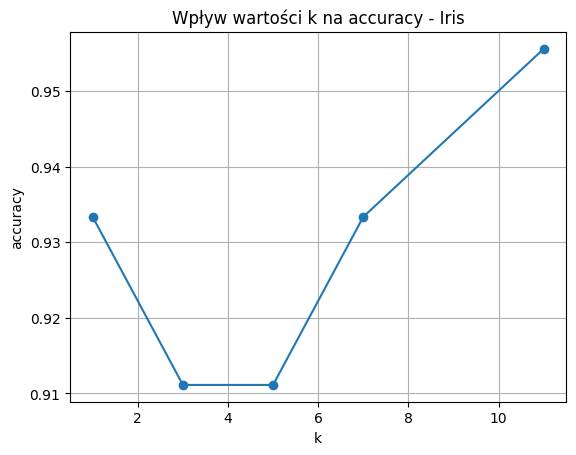

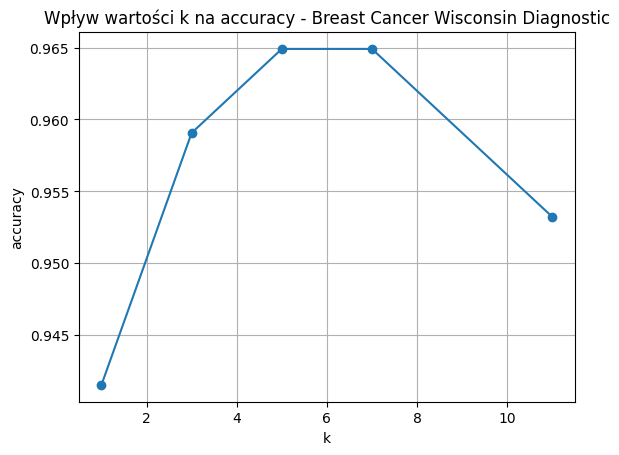

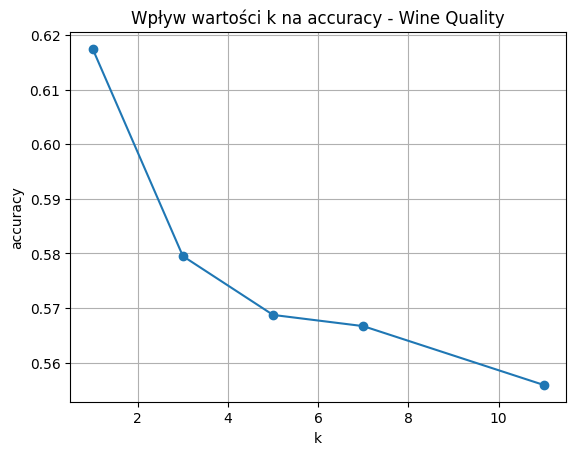

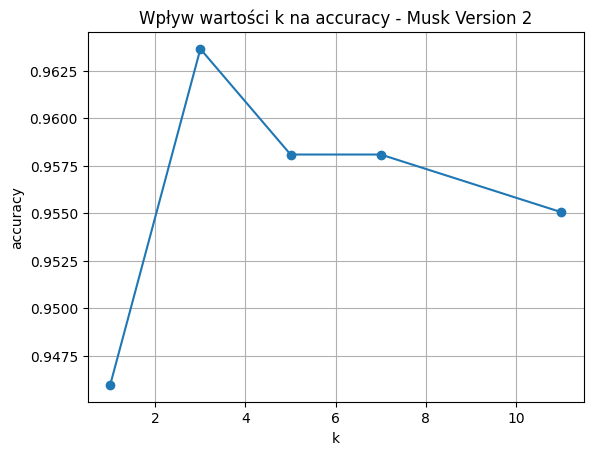

In [14]:
plot_knn_results(results)

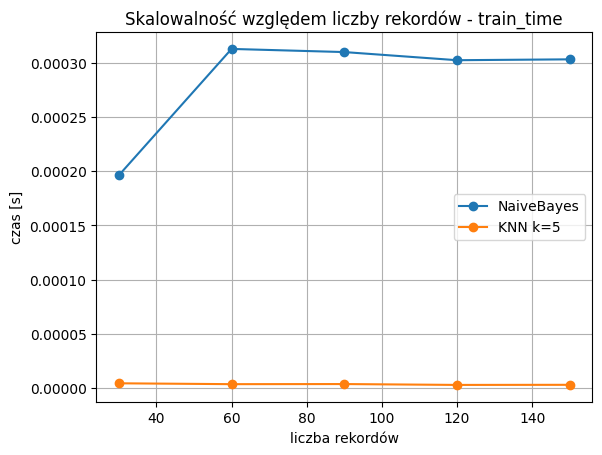

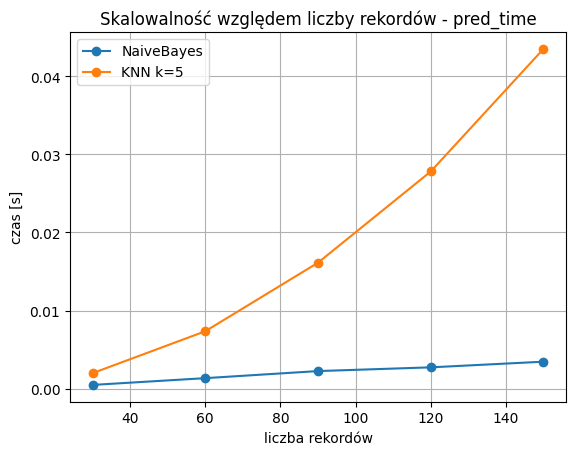

In [15]:
first_name = list(datasets.keys())[0]
size_results = run_size_experiment(datasets[first_name]["X"], datasets[first_name]["y"], first_name)
size_results.round(4)

size_results.to_csv("size_results_nb_knn.csv", index=False)
plot_size_results(size_results)